## Generate dataset for multiplication only

- a from [0, 1000]
- b from [0, 1000]

Format is JSON:
```
[
    {
       input: [a, b],
       target: a * b
    }
    ...
    ...
]
```

In [1]:
import random
import json

dataset = []

for _ in range(10_000):
    a = random.randint(0, 100)
    b = random.randint(0, 100)
    target = a * b
    data = {
        'input': { 'a': str(a), 'b': str(b) },
        'target': str(target)
    }
    dataset.append(data)

for _ in range(100_000):
    a = random.randint(100, 1000)
    b = random.randint(100, 1000)
    target = a * b
    data = {
        'input': { 'a': str(a), 'b': str(b) },
        'target': str(target)
    }
    dataset.append(data)

for _ in range(290_000):
    a = random.randint(1000, 10_000)
    b = random.randint(1000, 10_000)
    target = a * b
    data = {
        'input': { 'a': str(a), 'b': str(b) },
        'target': str(target)
    }
    dataset.append(data)

print(json.dumps(dataset[:5], indent=4))
print(f"completed dataset creation of size {len(dataset)}....")

[
    {
        "input": {
            "a": "82",
            "b": "13"
        },
        "target": "1066"
    },
    {
        "input": {
            "a": "23",
            "b": "37"
        },
        "target": "851"
    },
    {
        "input": {
            "a": "75",
            "b": "22"
        },
        "target": "1650"
    },
    {
        "input": {
            "a": "24",
            "b": "63"
        },
        "target": "1512"
    },
    {
        "input": {
            "a": "25",
            "b": "61"
        },
        "target": "1525"
    }
]
completed dataset creation of size 400000....


In [2]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import torch.optim as optim
from train_util import Trainer
from tokenizer import DigitTokenizer
from torch.optim.lr_scheduler import LambdaLR

DATA_DIR = "/teamspace/studios/this_studio/SAIR-competition-modular-math/data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

rand_seed = 42

batch_size = 64
max_seq_len = 12 # very small context window...
d_model = 512
num_heads = 4
lr = 1e-4

Training on device: cuda


In [3]:
# Multiplication only for now ...
tokenizer = DigitTokenizer()
eq_id = tokenizer.char_to_int["="]
eos_id = tokenizer.char_to_int["<eos>"]
pad_id = tokenizer.char_to_int["<pad>"]
tokenized_input = []

for sample in dataset:
    input_obj = sample["input"]
    str_tgt = sample["target"]
    str_a = input_obj['a']
    str_b = input_obj['b']

    a_token_id = tokenizer.encode(str_a)
    b_token_id = tokenizer.encode(str_b)
    tgt_token_id = tokenizer.encode(str_tgt)
    # KEY DECISION: reversing each input token so QKt aligns during math operations digit wise, from small to big
    a_token_id.reverse(), b_token_id.reverse(), tgt_token_id.reverse()
    tgt_token_id.append(eos_id)

    if len(a_token_id) < max_seq_len:
        a_token_id = a_token_id + [pad_id] * (max_seq_len - len(a_token_id))
    else:
        a_token_id = a_token_id[:max_seq_len]
    
    if len(b_token_id) < max_seq_len:
        b_token_id = b_token_id + [pad_id] * (max_seq_len - len(b_token_id))
    else:
        b_token_id = b_token_id[:max_seq_len]
    
    if len(tgt_token_id) < max_seq_len:
        tgt_token_id = tgt_token_id + [pad_id] * (max_seq_len - len(tgt_token_id))
    else:
        tgt_token_id = tgt_token_id[:max_seq_len]

    tokenized_input.append([a_token_id, b_token_id, tgt_token_id])


dataset_tensor = torch.tensor(tokenized_input, dtype=torch.long)

print(f"Dataset securely loaded in-memory. Matrix shape: {dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(dataset_tensor[:3])

Dataset securely loaded in-memory. Matrix shape: torch.Size([400000, 3, 12])
The <eos> token id is: 14
tensor([[[ 2,  8, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 3,  1, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 6,  6,  0,  1, 14, 13, 13, 13, 13, 13, 13, 13]],

        [[ 3,  2, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 7,  3, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 1,  5,  8, 14, 13, 13, 13, 13, 13, 13, 13, 13]],

        [[ 5,  7, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 2,  2, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 0,  5,  6,  1, 14, 13, 13, 13, 13, 13, 13, 13]]])


In [4]:
train_loader, val_loader, test_loader = Trainer.dataset_tensor_to_loader(
    dataset_tensor,
    train_percent = 0.8,
    val_percent = 0.1,
    batch_size = batch_size,
    rand_seed = rand_seed,
)

print(f"Train Loader: {len(train_loader)} batches")
print(f"Val Loader:   {len(val_loader)} batches")
print(f"Test Loader:  {len(test_loader)} batches")

Train Loader: 5000 batches
Val Loader:   625 batches
Test Loader:  625 batches


In [5]:
# This is dataset tensor for baseline standard GPT2 transformer ...
tokenized_standard_input = []

for sample in dataset:
    input_obj = sample["input"]
    str_tgt = sample["target"]
    str_a = input_obj['a']
    str_b = input_obj['b']
    
    standard_str_input = f"{str_a}*{str_b}={str_tgt}"
    standard_encoded_input = tokenizer.encode(standard_str_input)
    standard_encoded_input.append(eos_id)
    
    if len(standard_encoded_input) < 64:
        standard_encoded_input = standard_encoded_input + [pad_id] * (64 - len(standard_encoded_input))
    else:
        standard_encoded_input = standard_encoded_input[:64]

    tokenized_standard_input.append(standard_encoded_input)


standard_dataset_tensor = torch.tensor(tokenized_standard_input, dtype=torch.long)

print(f"Standard dataset securely loaded in-memory. Matrix shape: {standard_dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(standard_dataset_tensor[:3])

Standard dataset securely loaded in-memory. Matrix shape: torch.Size([400000, 64])
The <eos> token id is: 14
tensor([[ 8,  2, 10,  1,  3, 12,  1,  0,  6,  6, 14, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [ 2,  3, 10,  3,  7, 12,  8,  5,  1, 14, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [ 7,  5, 10,  2,  2, 12,  1,  6,  5,  0, 14, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13]])


In [6]:
train_loader_std, val_loader_std, test_loader_std = Trainer.dataset_tensor_to_loader(
    standard_dataset_tensor,
    train_percent = 0.8,
    val_percent = 0.1,
    batch_size = 64,
    rand_seed = rand_seed,
)

print(f"Train Loader: {len(train_loader_std)} batches")
print(f"Val Loader:   {len(val_loader_std)} batches")
print(f"Test Loader:  {len(test_loader_std)} batches")

Train Loader: 5000 batches
Val Loader:   625 batches
Test Loader:  625 batches


In [8]:
'''
Using standard GPT2 transformer model as baseline
'''
from transformers import GPT2Config, GPT2LMHeadModel

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,   
    n_embd=384,                       
    n_layer=6,                         
    n_head=6,                          
    n_ctx=64,                        
    bos_token_id=None,                 
    eos_token_id=tokenizer.char_to_int["<eos>"],
    pad_token_id=tokenizer.char_to_int["<pad>"]
)

baseline_model = GPT2LMHeadModel(config).to(device)

num_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params:,}")

Total Trainable Parameters: 11,046,912


In [9]:
'''
Training loop for baseline model...
'''
eq_id = tokenizer.char_to_int["="]
eos_id = tokenizer.char_to_int["<eos>"]
pad_id = tokenizer.char_to_int["<pad>"]
vocab_size = tokenizer.vocab_size
std_trainer = Trainer(device=device)
std_optimizer = optim.AdamW(
    baseline_model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.99),
    weight_decay=0.1,
)
std_loss_fct = nn.CrossEntropyLoss(
    reduction="none",
    ignore_index=pad_id
)
warmup_steps = 100

In [10]:
'''
Loading standard model checkpoint ....
'''
std_trainer.load_checkpoint("baseline_gpt2_epoch_38.pt", baseline_model, std_optimizer)

📂 Loading checkpoint: /teamspace/studios/this_studio/SAIR-competition-modular-math/checkpoints/baseline_gpt2_epoch_38.pt...
Successfully restored state from baseline_gpt2_epoch_38.pt (Epochs completed: 39)


{'model_state_dict': OrderedDict([('transformer.wte.weight',
               tensor([[-0.1650,  0.2295, -0.1161,  ..., -0.0737, -0.1192, -0.0009],
                       [ 0.2215, -0.0659, -0.0823,  ...,  0.1452,  0.1103, -0.0044],
                       [ 0.1636,  0.2863, -0.0727,  ..., -0.1214,  0.0946,  0.0253],
                       ...,
                       [-0.1405, -0.0226, -0.4403,  ...,  0.0661,  0.1378,  0.2456],
                       [-0.2006,  0.1844,  0.1436,  ..., -0.0666, -0.1628,  0.3194],
                       [-0.1405, -0.0226, -0.4403,  ...,  0.0661,  0.1378,  0.2456]],
                      device='cuda:0')),
              ('transformer.wpe.weight',
               tensor([[ 9.1299e-02,  1.8314e-01, -1.6839e-01,  ..., -4.6485e-02,
                         4.0124e-02,  4.4505e-02],
                       [ 1.1880e-02, -1.2396e-01,  9.2026e-02,  ...,  6.8798e-02,
                        -6.3895e-02,  5.4396e-02],
                       [-2.7881e-02,  2.0288e-02, -5

In [ ]:
def gen_loss_mask(targets: torch.Tensor):
    batch_size, seq_len = targets.shape
    eq_indices = (targets == eq_id).int().argmax(dim=-1).reshape(batch_size, 1)
    eos_indices = (targets == eos_id).int().argmax(dim=-1).reshape(batch_size, 1)
    pos_grid = torch.arange(seq_len).reshape(1, seq_len).to(device)
    loss_mask = ((pos_grid > eq_indices) & (pos_grid <= eos_indices)).view(-1)
    
    return loss_mask

def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor, loss_mask: torch.Tensor):
    batch_size, seq_len = targets.shape
    
    # Ensure masks and predictions are the right shape
    loss_mask = loss_mask.reshape(batch_size, seq_len)
    predictions = logits.argmax(dim=-1)
    
    # 1. Find which individual tokens match the target exactly
    correct_tokens = (predictions == targets)
    
    # 2. A token is considered "good" if it is correct OR if we don't care about it (outside the loss_mask)
    valid_tokens = correct_tokens | (~loss_mask)
    
    # 3. CRITICAL STEP: The entire sequence is only correct if ALL tokens in it are "good"
    exact_sequence_match = valid_tokens.all(dim=-1)
    
    # 4. Return the percentage of perfectly correct sequences in this batch (0.0 to 1.0)
    return exact_sequence_match.float().mean()

def lr_lambda(current_step):
    current_step = 1 if current_step == 0 else current_step
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    return 1.0

std_scheduler = LambdaLR(std_optimizer, lr_lambda=lr_lambda)

def train_model(num_epochs_to_add: int):
    start_epoch = len(std_trainer.train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add

    for epoch in range(start_epoch, target_epoch):
        baseline_model.train()
        total_train_loss = 0.0
        total_val_loss = 0.0
        total_train_accuracy = 0.0
        total_val_accuracy = 0.0

        for batch_sequences in tqdm(train_loader_std, desc=f"Epoch {epoch+1} Training"):
            batch_sequences = batch_sequences.to(device)
            inputs  = batch_sequences[:, :-1].contiguous()
            targets = batch_sequences[:, 1:].contiguous()

            # Generating attention mask for input and loss mask for output ...
            attention_mask = (inputs != pad_id).long()
            loss_mask = gen_loss_mask(targets)
            logits = baseline_model(inputs, attention_mask=attention_mask).logits
            loss = std_loss_fct(logits.view(-1, vocab_size), targets.view(-1))
            loss = loss[loss_mask].mean()
            accuracy = compute_accuracy(logits, targets, loss_mask)

            
            std_optimizer.zero_grad()
            loss.backward()
            std_optimizer.step()
            std_scheduler.step()
            total_train_loss += loss.item()
            total_train_accuracy += accuracy.item()

        baseline_model.eval()
        with torch.no_grad():
            for batch_sequences in tqdm(val_loader_std, desc=f"Epoch {epoch+1} Validation"):
                batch_sequences = batch_sequences.to(device)
                inputs  = batch_sequences[:, :-1].contiguous()
                targets = batch_sequences[:, 1:].contiguous()

                # Need to also apply attention mask and loss mask ...
                attention_mask = (inputs != pad_id).long()
                loss_mask = gen_loss_mask(targets)
                logits = baseline_model(inputs, attention_mask=attention_mask).logits
                loss = std_loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss = loss[loss_mask].mean()
                accuracy = compute_accuracy(logits, targets, loss_mask)
                
                total_val_loss += loss.item()
                total_val_accuracy += accuracy.item()

        avg_train_loss = total_train_loss / len(train_loader_std)
        avg_val_loss   = total_val_loss / len(val_loader_std)
        avg_train_accuracy = total_train_accuracy / len(train_loader_std)
        avg_val_accuracy   = total_val_accuracy / len(val_loader_std)
        std_trainer.add_loss_and_accuracy(avg_train_loss, avg_val_loss, avg_train_accuracy, avg_val_accuracy)

        std_trainer.plot_live_loss(
            current_epoch=epoch,
            total_target_epochs=target_epoch
        )

        if epoch > 20 & epoch % 5 == 0:
            std_trainer.save_checkpoint(f"baseline_gpt2_epoch_{epoch}", baseline_model, std_optimizer)

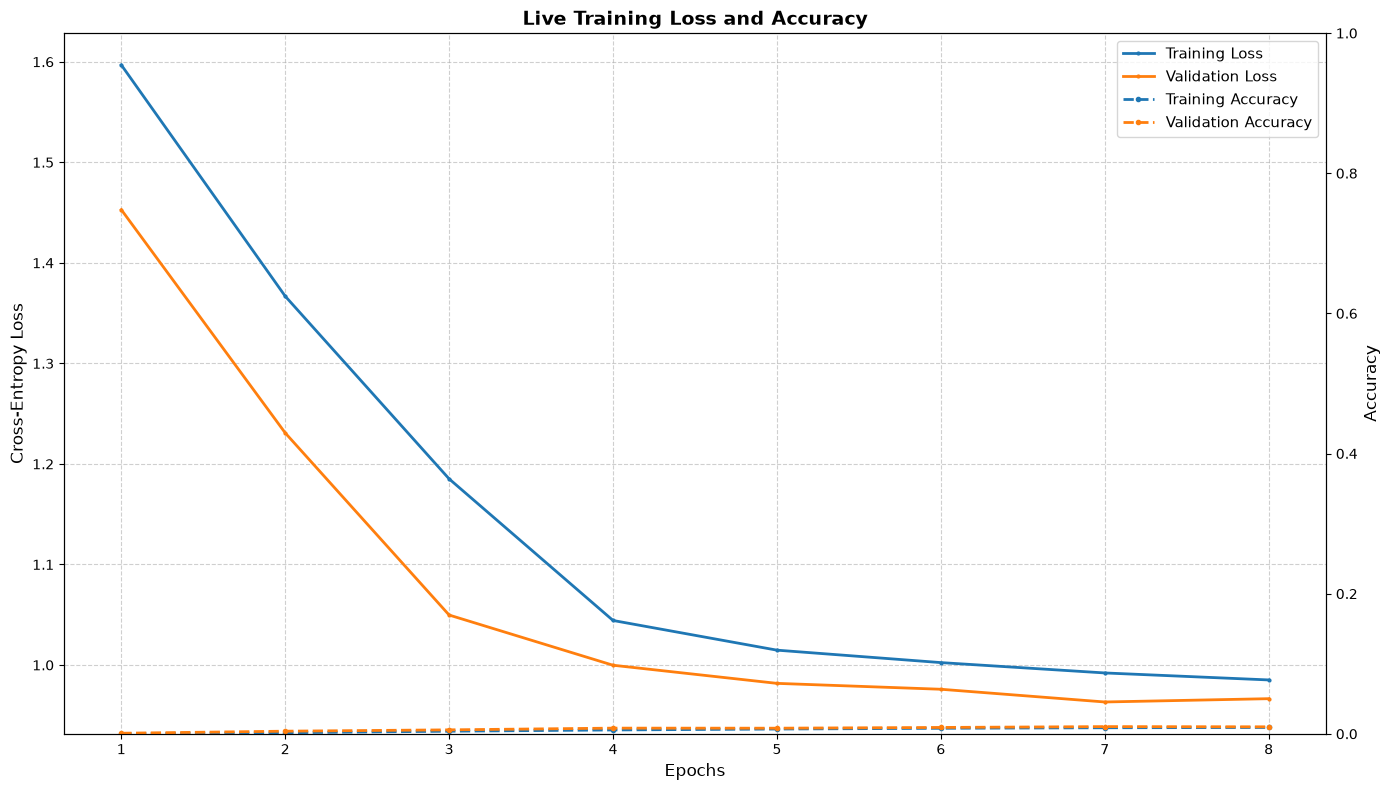

Latest Stats -> Epoch 07/40 | Train Loss: 0.9852 | Val Loss: 0.9665 | Train Acc: 0.0091 | Val Acc: 0.0100
Checkpoint manually saved as: /teamspace/studios/this_studio/SAIR-competition-modular-math/checkpoints/baseline_gpt2_epoch_7.pt


Epoch 9 Training:   0%|          | 0/5000 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

In [ ]:
train_model(40)

In [38]:
'''
Just trying to see if this setup can even learn simple multiplication first...
'''
from rope import RoPE

d_k = d_model // num_heads
rope = RoPE(
    d_head=d_k,
    max_seq_len=max_seq_len
)
embedding = nn.Embedding(num_embeddings=tokenizer.vocab_size, embedding_dim=d_model)
pre_attention_layernorm = nn.LayerNorm(d_model)
q_linear = nn.Linear(d_model, d_model)
k_linear = nn.Linear(d_model, d_model)
ffn = nn.Sequential(
            nn.Linear(max_seq_len, 2 * max_seq_len),
            nn.ReLU(),                                 
            nn.Linear(2 * max_seq_len, max_seq_len)
        )
final_layernorm = nn.LayerNorm(max_seq_len)
output_linear = nn.Linear(max_seq_len, tokenizer.vocab_size)



# single run with 1 sample for training
sample = dataset_tensor[0]
a, b, tgt = sample

a_embed = embedding(a)
b_embed = embedding(b)

a_norm1 = pre_attention_layernorm(a_embed)
b_norm1 = pre_attention_layernorm(b_embed)

q = q_linear(a_norm1).view(max_seq_len, num_heads, d_k).transpose(0, 1)
k = k_linear(b_norm1).view(max_seq_len, num_heads, d_k).transpose(0, 1)

q, k = rope(q, k)
score = torch.matmul(q, k.transpose(-2, -1)) / (d_k ** 0.5)
# explicitly skip softmax, and v ....
ffn_out = ffn(score)
final_norm = final_layernorm(ffn_out)
logits = output_linear(final_norm)
